# Image generation
1) Create coordinate grid
   1) All unique pairs (input_18, input_19) forms the backbone grid
2) Create unique classes
   1) All unique elements in input_1 is a class
3) For each unique class, construct an image with (22-3)input  + 3 output channels with the grid coordinate templates.
   1) The -3 is because the inputs 18,19 and 1 are no longer to be considered
4) For every grid coordinate missing, leave the image and channel as NaN
5) For every duplicate coordinate, construct a new image with (22-3) inputs + 3 outputs channels.

```
Tabular rows
    ↓
Group rows by input_1
    ↓
Map each row to a pixel using input_18 and input_19
    ↓
Store remaining input variables as input image channels
    ↓
Store output_1, output_2, output_3 as output image channels
```

In [1]:

from pathlib import Path
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "src" / "data" / "SmartEM" / "Philips").exists():
    repo_root = repo_root.parents[2]

data_dir = repo_root / "src" / "data" / "SmartEM" / "Philips"

input_data = pd.read_csv(data_dir / "input.csv")
output_data = pd.read_csv(data_dir / "output.csv")
grid_data = pd.read_csv(data_dir / "PATH_Ref_62_CatchRing.csv")
# input_data, output_data

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Image generation
# -----------------------------

class_col = "input_1"
x_col = "input_18"
y_col = "input_19"

output_channel_cols = ["output_1", "output_2", "output_3"]
# All input columns except class_col, x_col, y_col becomes a "channel"
input_channel_cols = [
    c for c in input_data.columns
    if c not in [class_col, x_col, y_col]
]

# Collects every unique coordinate pair appearing in the entire dataset.
coord_pairs = (
    input_data[[x_col, y_col]]
    .drop_duplicates()
    .sort_values([y_col, x_col])
    .reset_index(drop=True)
)

x_vals = np.sort(coord_pairs[x_col].unique())
y_vals = np.sort(coord_pairs[y_col].unique())

height = len(y_vals)
width = len(x_vals)

# These dictionaries translate physical coordinates into image indices.
x_to_col = {x: i for i, x in enumerate(x_vals)}
y_to_row = {y: i for i, y in enumerate(y_vals)}

# Marks which rectangular grid cells are real coordinate pairs
valid_coord_mask = np.zeros((height, width), dtype=bool)

for _, row in coord_pairs.iterrows():
    r = y_to_row[row[y_col]]
    c = x_to_col[row[x_col]]
    valid_coord_mask[r, c] = True

input_blocks = []
output_blocks = []
image_input_1 = []
# Check physical validity before generating any images:
# output_3 is cut_length and input_20 is initial_length.
# A cut hair cannot become longer than its initial length.
# Equality and floating-point differences up to 1e-9 are allowed.
length_tolerance = 1e-9

length_difference = output_data["output_3"] - input_data["input_20"]

invalid_length_mask = length_difference > length_tolerance

if invalid_length_mask.any():
    invalid_rows = pd.DataFrame({
        class_col: input_data.loc[invalid_length_mask, class_col],
        x_col: input_data.loc[invalid_length_mask, x_col],
        y_col: input_data.loc[invalid_length_mask, y_col],
        "input_20_initial_length": input_data.loc[invalid_length_mask, "input_20"],
        "output_3_cut_length": output_data.loc[invalid_length_mask, "output_3"],
        "output_minus_input": length_difference.loc[invalid_length_mask],
    })

    raise ValueError(
        "Invalid hair-length data found: output_3 (cut_length) exceeds "
        "input_20 (initial_length) by more than 1e-9 for at least one row. "
        "A hair cannot be longer after cutting.\n\n"
        f"{invalid_rows.to_string(index=True)}"
    )
# processes rows separately for each value of input_1.
for class_value, df_class in input_data.groupby(class_col, sort=False, dropna=False):
    df_class = df_class.copy()

    # Copy the corresponding output_3 values into df_class so they can be used for sorting.
    df_class["_sort_output_3"] = output_data.loc[df_class.index, "output_3"]

    # Within each coordinate pair, rank rows from largest output hair length
    # to smallest output hair length.
    # input_20 is used only if two rows have the same output_3.
    df_class = df_class.sort_values(
        by=[x_col, y_col, "_sort_output_3", "input_20"],
        ascending=[True, True, False, False],
        kind="mergesort",
    )

    # Duplicate coordinate PAIRS within this input_1 class become extra images.
    # Within one input_1 group, the same coordinate pair may appear more than once.
    # After sorting, _duplicate_i is now the sequence rank within each independent pixel:
    # 0 = highest output_3, 1 = second highest output_3, ..., last = lowest input_20.
    df_class["_duplicate_i"] = df_class.groupby(
        [x_col, y_col],
        sort=False,
        dropna=False,
    ).cumcount()

    # repeated rows become additional images.
    # Each image now represents one rank layer across all independent pixels:
    # image 0 = largest output_3 at each pixel,
    # image 1 = second-largest output_3 at each pixel, and so on.
    n_class_images = int(df_class["_duplicate_i"].max()) + 1

    # For each input_1 group, the input image tensor has shape:
    # (number_of_images, height, width, number_of_input_channels)
    print(
        f"input_1 = {class_value}: "
        f"{n_class_images} ranked images generated, "
        f"from longest to shortest per coordinate"
    )

    class_input_images = np.full(
        (n_class_images, height, width, len(input_channel_cols)),
        np.nan,
        dtype=object,
    )

    # (number_of_images, height, width, 3)
    class_output_images = np.full(
        (n_class_images, height, width, len(output_channel_cols)),
        np.nan,
        dtype=float,
    )

    # Each row is assigned to the appropriate image position.
    # Rows with missing coordinates are skipped.
    for idx, row in df_class.iterrows():
        x = row[x_col]
        y = row[y_col]

        if pd.isna(x) or pd.isna(y):
            continue

        # img_i is the rank of this observation within its coordinate pair.
        # 0 = largest output_3, 1 = second-largest output_3, etc.
        img_i = int(row["_duplicate_i"])

        r = y_to_row[y]
        c = x_to_col[x]

        # All input variables for that row are placed into the corresponding pixel location.
        # pixel at position (r, c) = [input channels]
        class_input_images[img_i, r, c, :] = row[input_channel_cols].to_numpy(dtype=object)

        out_row = output_data.loc[idx]
        class_output_images[img_i, r, c, 0] = out_row["output_1"]
        class_output_images[img_i, r, c, 1] = out_row["output_2"]
        class_output_images[img_i, r, c, 2] = out_row["output_3"]

    # For each input_1 group, its generated images are collected.
    input_blocks.append(class_input_images)
    output_blocks.append(class_output_images)
    image_input_1.extend([class_value] * n_class_images)

print("Done")
# (total_generated_images, height, width, number_of_input_channels)
input_images = np.concatenate(input_blocks, axis=0)
# (total_generated_images, height, width, 3)
output_images = np.concatenate(output_blocks, axis=0)
# (total_generated_images,)
image_input_1 = np.array(image_input_1)

# Individual channel images, each with shape:
# (n_images, height, width, 1)
input_channel_images = [
    input_images[:, :, :, i:i+1]
    for i in range(input_images.shape[-1])
]

output_channel_images = [
    output_images[:, :, :, i:i+1]
    for i in range(output_images.shape[-1])
]

print("height:", height)
print("width:", width)
print("valid coordinate pairs:", valid_coord_mask.sum())
print("input_images shape:", input_images.shape)
print("output_images shape:", output_images.shape)
print("number of input channel images:", len(input_channel_images))
print("one input channel image shape:", input_channel_images[0].shape)
print("number of output channel images:", len(output_channel_images))
print("one output channel image shape:", output_channel_images[0].shape)
print("image_input_1 shape:", image_input_1.shape)


input_1 = C01: 68 ranked images generated, from longest to shortest per coordinate
input_1 = C03: 91 ranked images generated, from longest to shortest per coordinate
input_1 = C05: 76 ranked images generated, from longest to shortest per coordinate
input_1 = C12: 61 ranked images generated, from longest to shortest per coordinate
input_1 = C18: 78 ranked images generated, from longest to shortest per coordinate
input_1 = C19: 63 ranked images generated, from longest to shortest per coordinate
input_1 = C20: 55 ranked images generated, from longest to shortest per coordinate
input_1 = C21: 68 ranked images generated, from longest to shortest per coordinate
input_1 = C22: 68 ranked images generated, from longest to shortest per coordinate
input_1 = C26: 76 ranked images generated, from longest to shortest per coordinate
input_1 = C30: 60 ranked images generated, from longest to shortest per coordinate
input_1 = C31: 55 ranked images generated, from longest to shortest per coordinate
inpu

# Sort Hairs, longest to shortest
1) Let's pick C01. There are 68 images in this class, but shuffled up.
2) sorting each pixel in each of the 68 images, image 1 will have highest input_20 and highes output_3
   1) image 2 will have second highest input_20 and second highest output_3
   2) image 68 will have lowest input_20 and lowest highest output_3
   3) In case there is a clash with input_20 value, choose the row with higher output_3.
      1) In case there is a clash again, pick any of them
This process is repeated for all classes

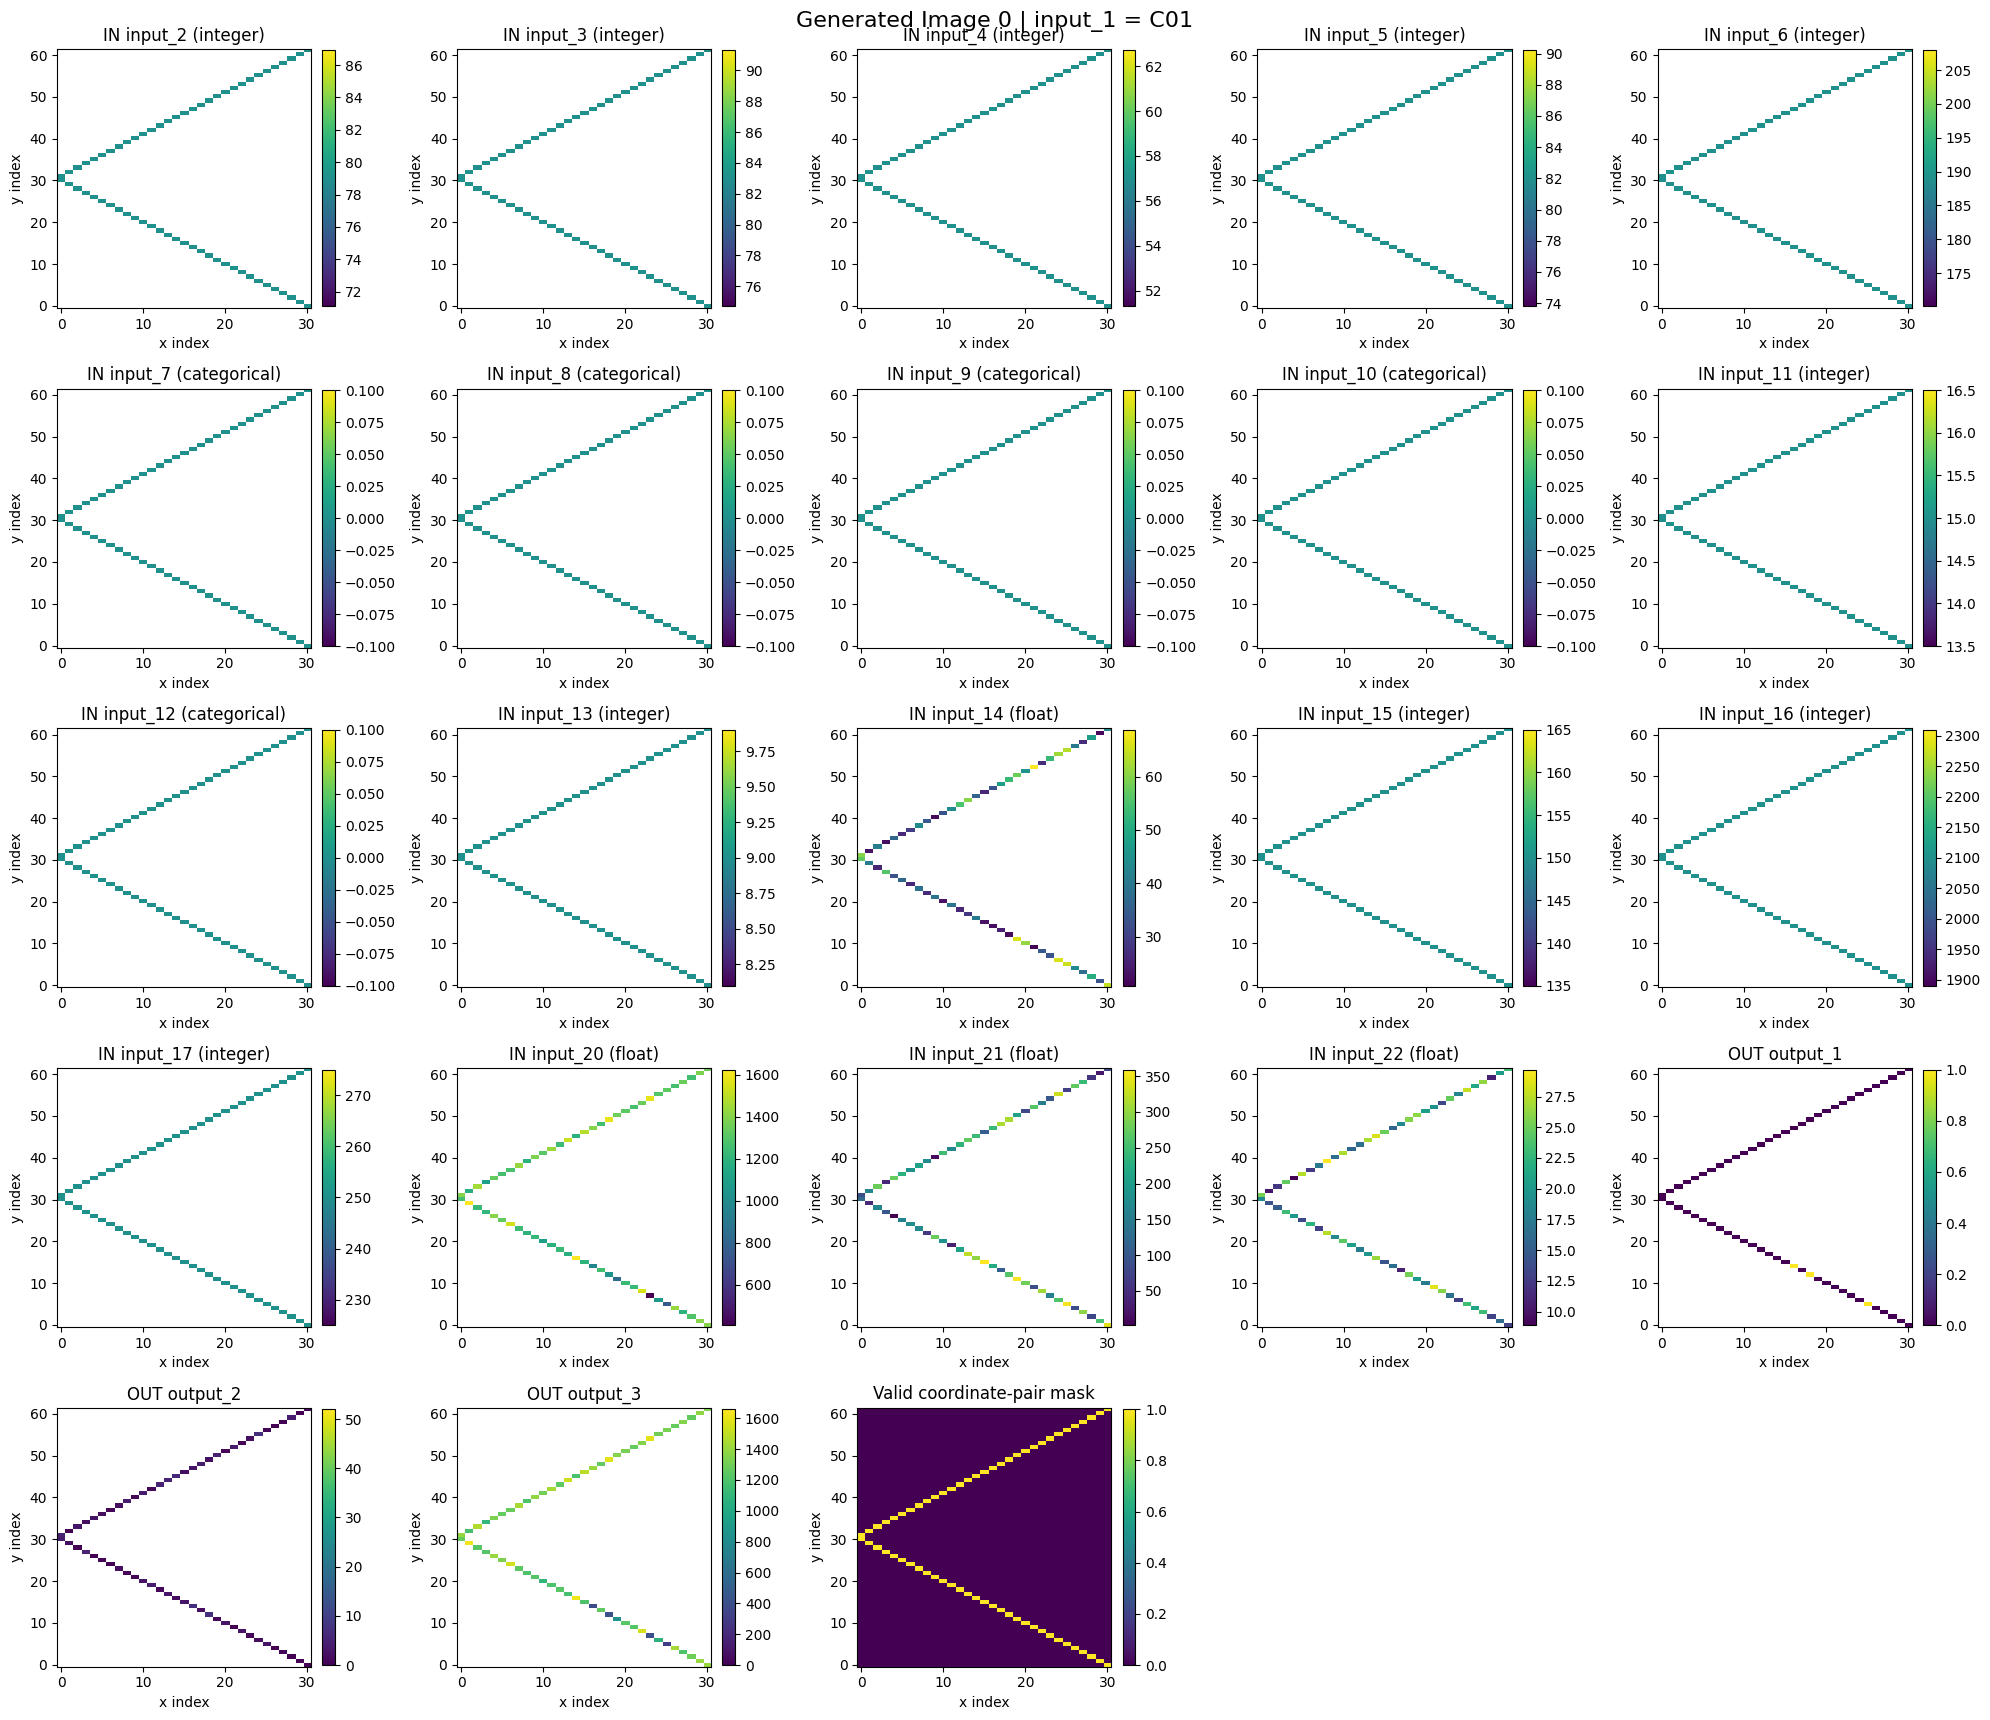

In [2]:


# -----------------------------
# Visualization
# -----------------------------

def channel_to_numeric_image(A, colname):
    flat = pd.Series(A.ravel())

    categorical_inputs = [1, 7, 8, 9, 10, 12]
    integer_inputs = [2, 3, 4, 5, 6, 11, 13, 15, 16, 17]

    categorical_cols = [f"input_{i}" for i in categorical_inputs]
    integer_cols = [f"input_{i}" for i in integer_inputs]

    if colname in categorical_cols:
        codes, _ = pd.factorize(flat, sort=True)
        codes = codes.astype(float)
        codes[codes < 0] = np.nan
        return codes.reshape(A.shape), "categorical"

    if colname in integer_cols:
        numeric = pd.to_numeric(flat, errors="coerce")
        return numeric.to_numpy().reshape(A.shape), "integer"

    numeric = pd.to_numeric(flat, errors="coerce")
    return numeric.to_numpy().reshape(A.shape), "float"


def show_generated_image(sample_idx=0):
    n_input = len(input_channel_cols)
    n_output = len(output_channel_cols)

    n_plots = n_input + n_output + 1
    n_cols = 5
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4 * n_cols, 3.5 * n_rows),
    )

    axes = np.asarray(axes).ravel()

    plot_i = 0

    for ch, colname in enumerate(input_channel_cols):
        A = input_images[sample_idx, :, :, ch]
        img, kind = channel_to_numeric_image(A, colname)

        ax = axes[plot_i]
        im = ax.imshow(img, origin="lower", aspect="auto")
        ax.set_title(f"IN {colname} ({kind})")
        ax.set_xlabel("x index")
        ax.set_ylabel("y index")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        plot_i += 1

    output_vmins = np.nanmin(output_images, axis=(0, 1, 2))
    output_vmaxs = np.nanmax(output_images, axis=(0, 1, 2))

    for ch, colname in enumerate(output_channel_cols):
        A = output_images[sample_idx, :, :, ch]

        ax = axes[plot_i]
        im = ax.imshow(
            A,
            origin="lower",
            aspect="auto",
            vmin=output_vmins[ch],
            vmax=output_vmaxs[ch],
        )

        ax.set_title(f"OUT {colname}")
        ax.set_xlabel("x index")
        ax.set_ylabel("y index")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        plot_i += 1

    ax = axes[plot_i]
    im = ax.imshow(valid_coord_mask.astype(float), origin="lower", aspect="auto")
    ax.set_title("Valid coordinate-pair mask")
    ax.set_xlabel("x index")
    ax.set_ylabel("y index")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plot_i += 1

    for ax in axes[plot_i:]:
        ax.axis("off")

    fig.suptitle(
        f"Generated Image {sample_idx} | input_1 = {image_input_1[sample_idx]}",
        fontsize=16,
    )

    plt.tight_layout()
    plt.show()


# Show first generated image
show_generated_image(sample_idx=0)

Classes found: [np.str_('C01'), np.str_('C03'), np.str_('C05'), np.str_('C12'), np.str_('C18'), np.str_('C19'), np.str_('C20'), np.str_('C21'), np.str_('C22'), np.str_('C26'), np.str_('C30'), np.str_('C31'), np.str_('C51')]
Shared length scale: -0.0543126648924499 to 1657.842135874233
Normalised length range: 0 to 1
Saved numeric GIF: /home/sa1/Documents/gitReps/pythonQuickAndDirty/src/data/SmartEM/Philips/generated_gifs/numeric_input_20_output_3_evolution_C01.gif
Saved normalised colour GIF: /home/sa1/Documents/gitReps/pythonQuickAndDirty/src/data/SmartEM/Philips/generated_gifs/normalised_colour_input_20_output_3_C01.gif
Saved numeric GIF: /home/sa1/Documents/gitReps/pythonQuickAndDirty/src/data/SmartEM/Philips/generated_gifs/numeric_input_20_output_3_evolution_C03.gif
Saved normalised colour GIF: /home/sa1/Documents/gitReps/pythonQuickAndDirty/src/data/SmartEM/Philips/generated_gifs/normalised_colour_input_20_output_3_C03.gif
Saved numeric GIF: /home/sa1/Documents/gitReps/pythonQuick

KeyboardInterrupt: 

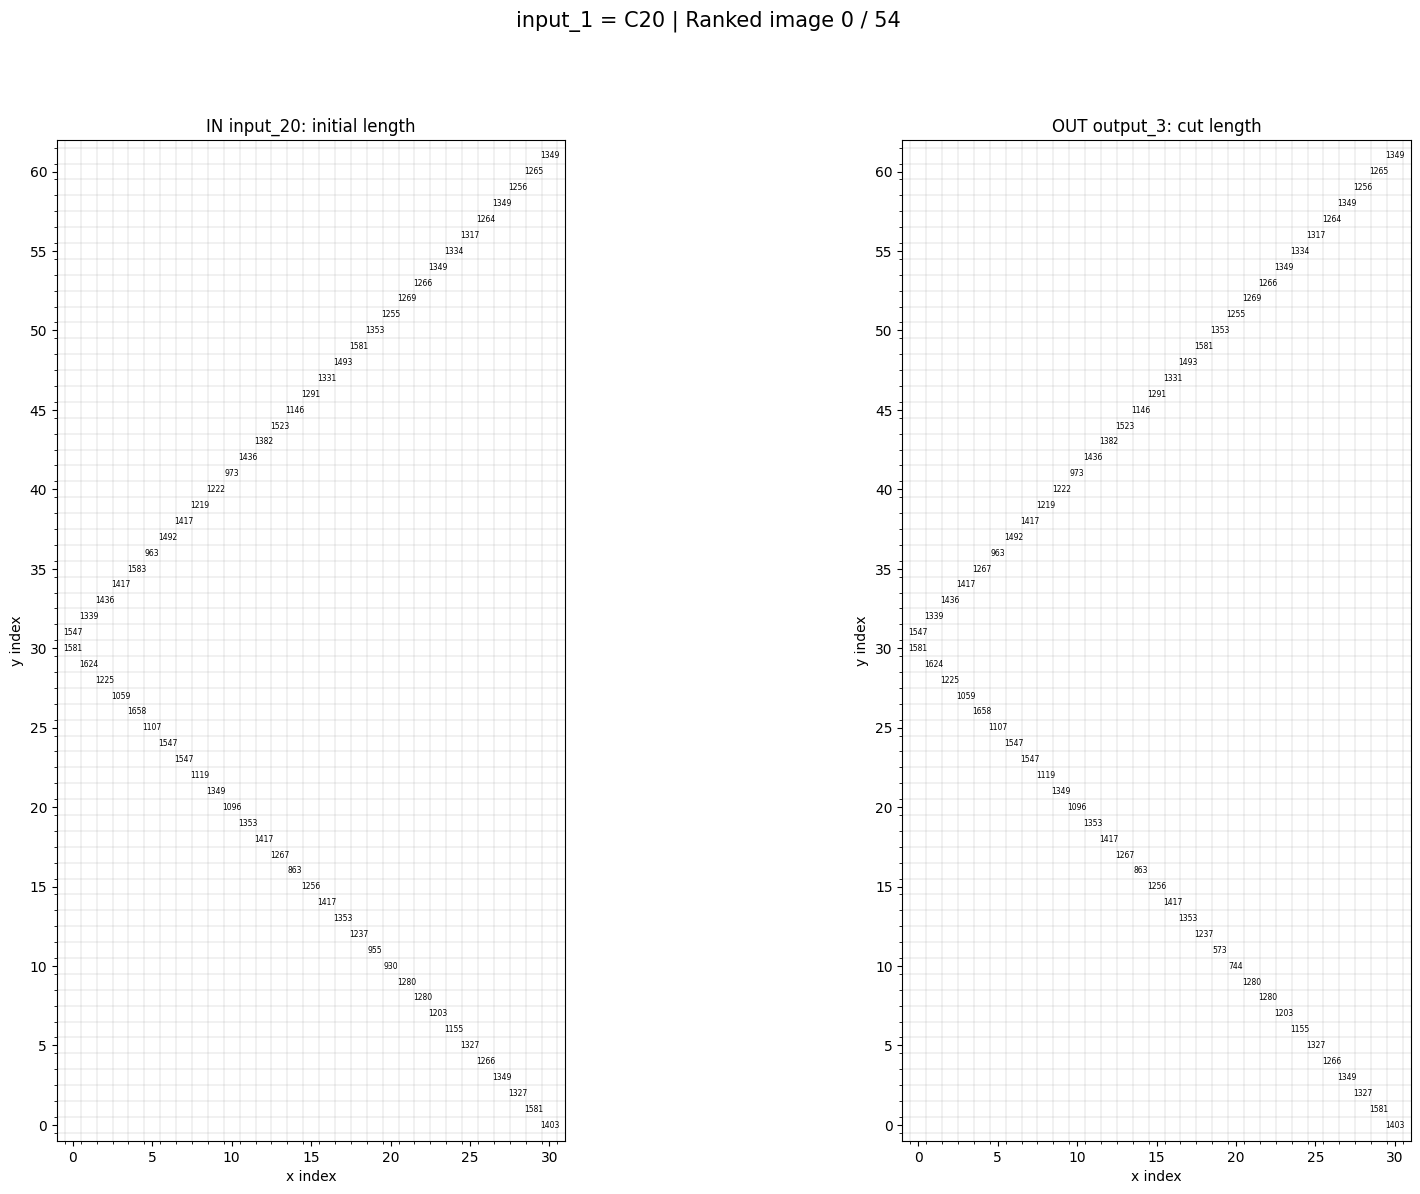

In [3]:
# -----------------------------
# GIF generation: evolution of input_20 and output_3 per input_1 class
# -----------------------------

from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import display, Image as IPythonImage

# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

input_length_col = "input_20"
output_length_col = "output_3"

gif_dir = data_dir / "generated_gifs"
gif_dir.mkdir(parents=True, exist_ok=True)

fps = 1.5
dpi = 120

# ---------------------------------------------------------
# Identify channel indices
# ---------------------------------------------------------

input_20_ch = input_channel_cols.index(input_length_col)
output_3_ch = output_channel_cols.index(output_length_col)

# Ensure numeric float arrays for plotting
input_20_images = pd.to_numeric(
    pd.Series(input_images[:, :, :, input_20_ch].ravel()),
    errors="coerce"
).to_numpy().reshape(input_images[:, :, :, input_20_ch].shape)

output_3_images = output_images[:, :, :, output_3_ch].astype(float)

# All available classes, retaining construction order
class_values = pd.unique(image_input_1)

# Indices of generated images belonging to each class
class_to_indices = {
    class_value: np.flatnonzero(image_input_1 == class_value)
    for class_value in class_values
}

# ---------------------------------------------------------
# Shared colour scale
# input_20 and output_3 are both hair lengths, so the same
# colour range allows direct visual comparison.
# ---------------------------------------------------------

combined_lengths = np.concatenate([
    input_20_images[np.isfinite(input_20_images)],
    output_3_images[np.isfinite(output_3_images)]
])

length_vmin = np.nanmin(combined_lengths)
length_vmax = np.nanmax(combined_lengths)

print("Classes found:", list(class_values))
print("Shared length scale:", length_vmin, "to", length_vmax)
# ---------------------------------------------------------
# Normalised versions for coloured GIFs
# ---------------------------------------------------------

def normalise_lengths(A, vmin=length_vmin, vmax=length_vmax):
    if np.isclose(vmax, vmin):
        raise ValueError("Cannot normalise lengths because all values are identical.")

    return (A - vmin) / (vmax - vmin)


input_20_images_normalised = normalise_lengths(input_20_images)
output_3_images_normalised = normalise_lengths(output_3_images)
# ---------------------------------------------------------
# Normalised length images using one shared global scale
# ---------------------------------------------------------

def normalise_length_images(A, vmin=length_vmin, vmax=length_vmax):
    """
    Min-max normalise hair lengths to [0, 1] using the same
    global scale for input_20 and output_3.

    NaN pixels remain NaN.
    """
    if np.isclose(vmax, vmin):
        raise ValueError("Cannot normalise lengths because all values are identical.")

    return (A - vmin) / (vmax - vmin)


input_20_images_normalised = normalise_length_images(input_20_images)
output_3_images_normalised = normalise_length_images(output_3_images)

print("Normalised length range: 0 to 1")

# ---------------------------------------------------------
# Helper: draw numeric values at valid pixel coordinates
# ---------------------------------------------------------

def draw_numeric_panel(ax, A, title, decimals=0):
    """
    Display numeric values at each available coordinate.
    No heatmap colours are used.
    """
    ax.clear()

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("x index")
    ax.set_ylabel("y index")

    ax.set_xlim(-1, width)
    ax.set_ylim(-1, height)
    ax.set_aspect("equal")

    # Light grid to help track individual pixel positions
    ax.set_xticks(np.arange(-0.5, width, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, height, 1), minor=True)
    ax.grid(which="minor", linewidth=0.25)

    # Show fewer numeric axis labels so the axis is not crowded
    ax.set_xticks(np.arange(0, width, 5))
    ax.set_yticks(np.arange(0, height, 5))

    for r in range(height):
        for c in range(width):
            value = A[r, c]

            if np.isfinite(value):
                ax.text(
                    c,
                    r,
                    f"{value:.{decimals}f}",
                    ha="center",
                    va="center",
                    fontsize=5.5,
                )


# ---------------------------------------------------------
# Helper: create one numeric GIF for one class
# ---------------------------------------------------------

def create_class_gif(class_value, save_dir=gif_dir, fps=fps, dpi=dpi):
    """
    Create one GIF for a single input_1 class.

    Each animation frame corresponds to one ranked generated image:
        frame 0 = largest output_3 at each coordinate
        frame 1 = second-largest output_3 at each coordinate
        ...
    """

    sample_indices = class_to_indices[class_value]
    n_frames = len(sample_indices)

    # Larger figure because values are written inside pixels
    fig, axes = plt.subplots(1, 2, figsize=(20, 13))

    title = fig.suptitle(
        f"input_1 = {class_value} | Ranked image 0 / {n_frames - 1}",
        fontsize=15,
    )

    def update(frame_i):
        sample_idx = sample_indices[frame_i]

        draw_numeric_panel(
            axes[0],
            input_20_images[sample_idx],
            "IN input_20: initial length",
            decimals=0,
        )

        draw_numeric_panel(
            axes[1],
            output_3_images[sample_idx],
            "OUT output_3: cut length",
            decimals=0,
        )

        title.set_text(
            f"input_1 = {class_value} | "
            f"Ranked image {frame_i} / {n_frames - 1}"
        )

        return axes

    animation = FuncAnimation(
        fig,
        update,
        frames=n_frames,
        interval=1000 / fps,
        blit=False,
        repeat=True,
    )

    safe_class_name = str(class_value).replace("/", "_").replace(" ", "_")
    gif_path = save_dir / f"numeric_input_20_output_3_evolution_{safe_class_name}.gif"

    animation.save(
        gif_path,
        writer=PillowWriter(fps=fps),
        dpi=dpi,
    )

    plt.close(fig)

    return gif_path

# ---------------------------------------------------------
# Helper: create one coloured normalised GIF for one class
# ---------------------------------------------------------

def create_class_normalised_colour_gif(
    class_value,
    save_dir=gif_dir,
    fps=fps,
    dpi=dpi,
):
    """
    Create one coloured GIF for a single input_1 class.

    Values are normalised to [0, 1] using one shared scale
    across input_20 and output_3.

    No numbers are written inside the pixels.
    """

    sample_indices = class_to_indices[class_value]
    n_frames = len(sample_indices)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    first_idx = sample_indices[0]

    im_input = axes[0].imshow(
        input_20_images_normalised[first_idx],
        origin="lower",
        aspect="auto",
        vmin=0,
        vmax=1,
        cmap="viridis",
    )

    im_output = axes[1].imshow(
        output_3_images_normalised[first_idx],
        origin="lower",
        aspect="auto",
        vmin=0,
        vmax=1,
        cmap="viridis",
    )

    axes[0].set_title("IN input_20: normalised initial length")
    axes[1].set_title("OUT output_3: normalised cut length")

    for ax in axes:
        ax.set_xlabel("x index")
        ax.set_ylabel("y index")

    # One colour bar because input and output use the same [0, 1] scale
    cbar = fig.colorbar(
        im_input,
        ax=axes,
        fraction=0.046,
        pad=0.04,
    )
    cbar.set_label("Normalised hair length")

    title = fig.suptitle(
        f"input_1 = {class_value} | Normalised colour map | "
        f"Ranked image 0 / {n_frames - 1}",
        fontsize=14,
    )

    def update(frame_i):
        sample_idx = sample_indices[frame_i]

        im_input.set_data(input_20_images_normalised[sample_idx])
        im_output.set_data(output_3_images_normalised[sample_idx])

        title.set_text(
            f"input_1 = {class_value} | Normalised colour map | "
            f"Ranked image {frame_i} / {n_frames - 1}"
        )

        return im_input, im_output, title

    animation = FuncAnimation(
        fig,
        update,
        frames=n_frames,
        interval=1000 / fps,
        blit=False,
        repeat=True,
    )

    safe_class_name = str(class_value).replace("/", "_").replace(" ", "_")
    gif_path = save_dir / f"normalised_colour_input_20_output_3_{safe_class_name}.gif"

    animation.save(
        gif_path,
        writer=PillowWriter(fps=fps),
        dpi=dpi,
    )

    plt.close(fig)

    return gif_path

# ---------------------------------------------------------
# Helper: create one normalised numeric GIF for one class
# ---------------------------------------------------------

def create_class_normalised_gif(class_value, save_dir=gif_dir, fps=fps, dpi=dpi):
    """
    Create one GIF for a single input_1 class using normalised length values.

    Both input_20 and output_3 are normalised using the same global
    length range, so their values remain directly comparable.

    Each animation frame corresponds to one ranked generated image:
        frame 0 = largest output_3 at each coordinate
        frame 1 = second-largest output_3 at each coordinate
        ...
    """

    sample_indices = class_to_indices[class_value]
    n_frames = len(sample_indices)

    fig, axes = plt.subplots(1, 2, figsize=(20, 13))

    title = fig.suptitle(
        f"input_1 = {class_value} | Normalised lengths | Ranked image 0 / {n_frames - 1}",
        fontsize=15,
    )

    def update(frame_i):
        sample_idx = sample_indices[frame_i]

        draw_numeric_panel(
            axes[0],
            input_20_images_normalised[sample_idx],
            "IN input_20: initial length normalised to [0, 1]",
            decimals=3,
        )

        draw_numeric_panel(
            axes[1],
            output_3_images_normalised[sample_idx],
            "OUT output_3: cut length normalised to [0, 1]",
            decimals=3,
        )

        title.set_text(
            f"input_1 = {class_value} | Normalised lengths | "
            f"Ranked image {frame_i} / {n_frames - 1}"
        )

        return axes

    animation = FuncAnimation(
        fig,
        update,
        frames=n_frames,
        interval=1000 / fps,
        blit=False,
        repeat=True,
    )

    safe_class_name = str(class_value).replace("/", "_").replace(" ", "_")
    gif_path = save_dir / f"normalised_numeric_input_20_output_3_evolution_{safe_class_name}.gif"

    animation.save(
        gif_path,
        writer=PillowWriter(fps=fps),
        dpi=dpi,
    )

    plt.close(fig)

    return gif_path


# ---------------------------------------------------------
# Generate one numeric GIF for every class
# ---------------------------------------------------------
individual_gif_paths = []
normalised_colour_gif_paths = []

for class_value in class_values:
    # Existing number-only GIF
    numeric_gif_path = create_class_gif(class_value)
    individual_gif_paths.append(numeric_gif_path)
    print(f"Saved numeric GIF: {numeric_gif_path}")

    # New coloured GIF with values normalised to [0, 1]
    colour_gif_path = create_class_normalised_colour_gif(class_value)
    normalised_colour_gif_paths.append(colour_gif_path)
    print(f"Saved normalised colour GIF: {colour_gif_path}")

print(f"\nCreated {len(individual_gif_paths)} numeric GIFs.")
print(f"Created {len(normalised_colour_gif_paths)} normalised colour GIFs.")